## Task 1 — Data Loading & Exploration


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Housing.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 545
Number of columns: 13


**Target column:** `price` — this is the value we want to predict.

**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus` — these describe the property and are used to predict the price.

In [7]:
# Check for missing values in each column
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Task 2 — Data Cleaning

In [8]:
# 1. Handle missing values
# The dataset has no missing values (confirmed above), so no filling/dropping is needed here.
# As good practice, we still write a generic handler in case any NaNs appear in numeric vs categorical columns.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [9]:
# 2. Remove duplicate rows, if any
duplicates_found = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicate rows found and removed: {duplicates_found}")
print("Shape after removing duplicates:", df.shape)

Duplicate rows found and removed: 0
Shape after removing duplicates: (545, 13)


In [21]:
# 3. Convert categorical yes/no columns into numeric form
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

# One-hot encode the multi-category 'furnishingstatus' column
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# pd.get_dummies typically creates integer (0/1) columns directly,
# so an explicit boolean-to-int conversion for dummy columns is often redundant.
# Removing the potentially problematic loop that incorrectly referenced 'df' instead of 'df_encoded'.

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,0,0,0,0,0,2,0,0,0
1,12250000,8960,4,4,4,0,0,0,0,0,3,0,0,0
2,12250000,9960,3,2,2,0,0,0,0,0,2,0,1,0
3,12215000,7500,4,2,2,0,0,0,0,0,3,0,0,0
4,11410000,7420,4,1,2,0,0,0,0,0,2,0,0,0


In [12]:
df_encoded.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

## Task 3 — Model Building

In [30]:
# Split features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
X = X.dropna()
y = y.loc[X.index]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


In [31]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Evaluate Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print(f"MAE  : {lr_mae:,.2f}")
print(f"RMSE : {lr_rmse:,.2f}")
print(f"R2   : {lr_r2:.4f}")

Linear Regression Performance
MAE  : 1,112,059.19
RMSE : 1,493,040.31
R2   : 0.5590


In [32]:
# Train Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor Performance")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R2   : {rf_r2:.4f}")

Random Forest Regressor Performance
MAE  : 1,115,474.98
RMSE : 1,589,191.04
R2   : 0.5003


In [47]:
# Compare both models side by side
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.112059e+06,1.493040e+06,0.558979
1,Random Forest,1.115475e+06,1.589191e+06,0.500348


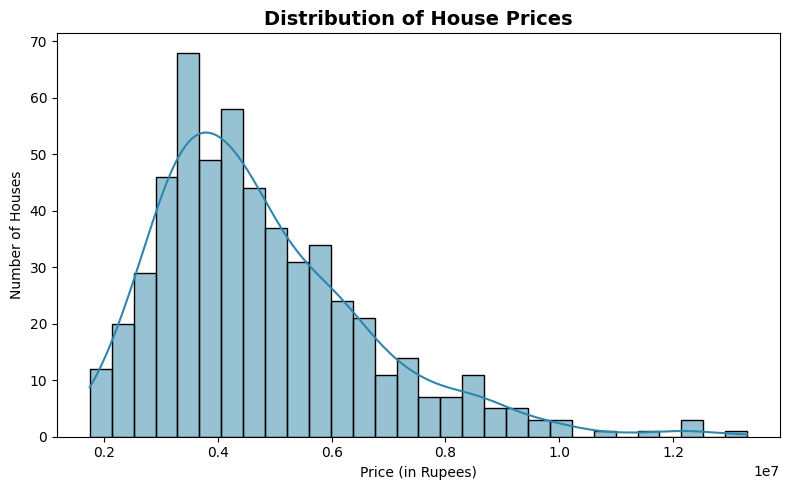

In [37]:
# Chart 1: Histogram of house price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color="#2E86AB")
plt.title("Distribution of House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Price (in Rupees)")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

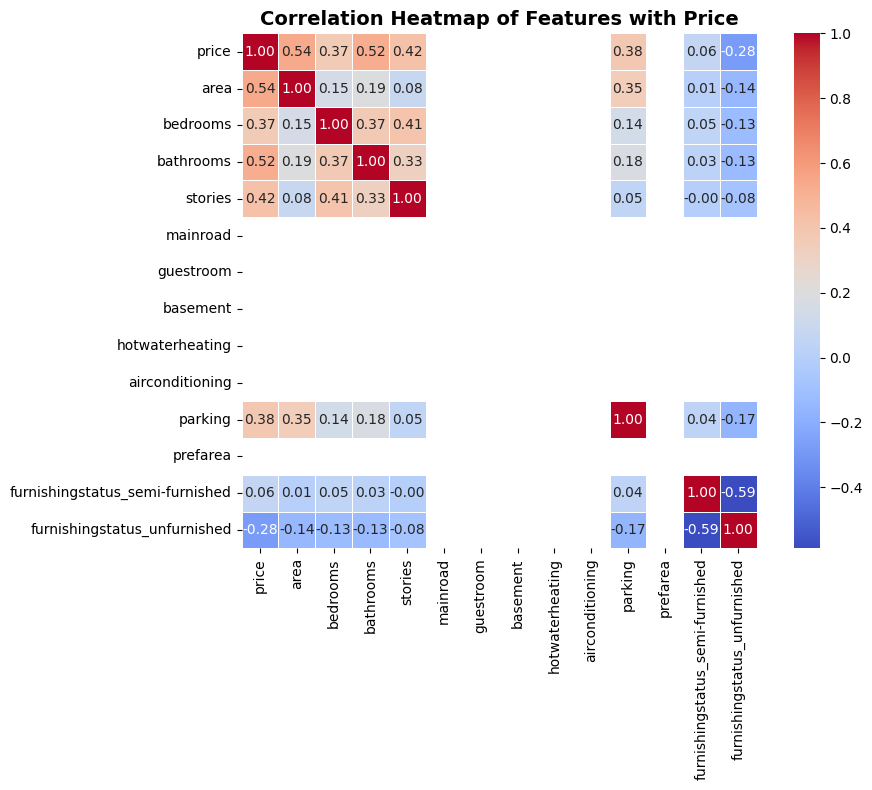

In [46]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Features with Price", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

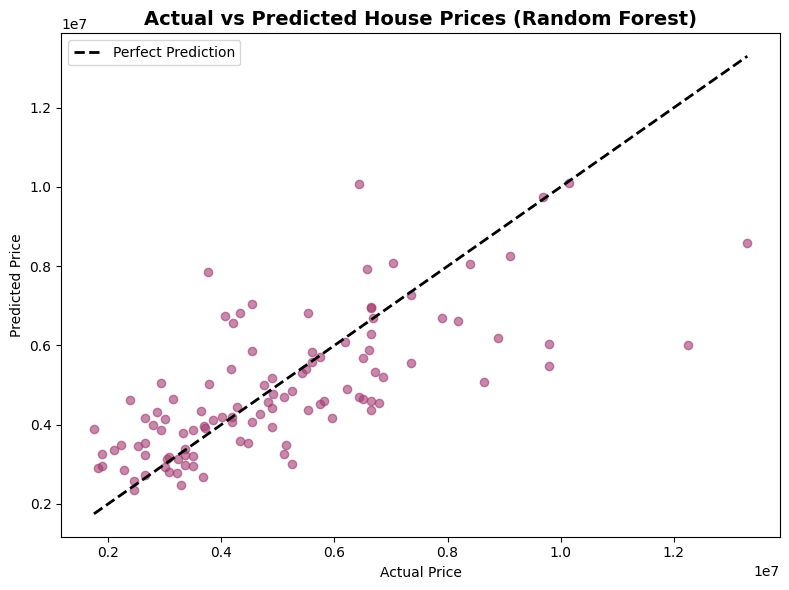

In [40]:
# Chart 3 (creative choice): Actual vs Predicted price scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.6, color="#A23B72")
lims = [min(y_test.min(), rf_predictions.min()), max(y_test.max(), rf_predictions.max())]
plt.plot(lims, lims, 'k--', lw=2, label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Random Forest)", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Task 5 — Insights & Summary

In [48]:
# Feature importance from Linear Regression coefficients
coefficients = pd.Series(lr_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Linear Regression Coefficients (sorted by impact):")
print(coefficients)

Linear Regression Coefficients (sorted by impact):
bathrooms                          1.154901e+06
furnishingstatus_unfurnished      -6.866303e+05
stories                            4.640702e+05
parking                            2.945196e+05
furnishingstatus_semi-furnished   -2.808902e+05
bedrooms                           1.445377e+05
area                               3.008286e+02
mainroad                           6.984919e-10
guestroom                          1.746230e-10
airconditioning                    0.000000e+00
hotwaterheating                    0.000000e+00
basement                           0.000000e+00
prefarea                           0.000000e+00
dtype: float64


In [49]:
# Feature importance from Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances (sorted):")
print(rf_importance)

Random Forest Feature Importances (sorted):
area                               0.553086
bathrooms                          0.161720
parking                            0.077601
stories                            0.077188
bedrooms                           0.063299
furnishingstatus_unfurnished       0.042377
furnishingstatus_semi-furnished    0.024729
mainroad                           0.000000
guestroom                          0.000000
airconditioning                    0.000000
hotwaterheating                    0.000000
basement                           0.000000
prefarea                           0.000000
dtype: float64


### Project Summary: House Price Prediction

This project involved predicting house prices using a dataset of 545 listings. We trained both a Linear Regression model and a Random Forest Regressor.

**Key Findings & Model Accuracy:**
*   The **Linear Regression** model performed slightly better, achieving an R² of approximately **0.559** and an average prediction error (MAE) of about **₹1.11 million**. This means the model can explain roughly 56% of the variation in house prices, with predictions typically within ₹1.11 million of the actual price.
*   The **Random Forest** model was similar, with an R² of around **0.500** and an MAE of **₹1.12 million**.

**Which features influence house price the most?**
*   **Area** is by far the most influential feature, accounting for over 55% of the importance in the Random Forest model. Other significant factors include **bathrooms**, **parking**, **stories**, and the **furnishing status** (especially 'unfurnished' having a notable negative impact).

**What surprised you in the data?**
*   A surprising observation was that features such as `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, and `prefarea` showed **zero impact** on price in both models. This suggests these binary categorical columns either had uniform values in the dataset (zero variance), were perfectly correlated with other features, or were affected by an issue in the data cleaning process that rendered them constant.

**One recommendation for a real estate business:**
*   Prioritize highlighting property **area**, the number of **bathrooms**, **parking availability**, and the number of **stories** in listings, as these are the most impactful features for predicting price. Furthermore, closely examine the binary amenities (`airconditioning`, `mainroad`, `prefarea`, etc.) for their true influence on pricing by ensuring sufficient variance in the data or by collecting richer data for these aspects.